# Retail Transaction Insights — Graded Mini Project (Part B)

**Design notes / assumptions**

- Input file: `Retail_Transactions_Dataset.csv` must be in the same folder as this notebook. The sample data used to produce the outputs below is the 15-row sample provided in the brief — replace the CSV with the full dataset and re-run all cells to get submission-ready figures.
- The `Product` column is stored as a string that looks like a Python list (e.g. `['Ketchup', 'Shaving Cream']`). It is parsed back into a real list with `ast.literal_eval` so individual products can be counted.
- `Discount_Applied` (TRUE/FALSE text) is converted to a real boolean.
- `Promotion`'s literal text `"None"` is treated as its own clean category, `"No Promotion"`, rather than a missing value.
- `Date` is parsed as day-first (`DD-MM-YYYY HH:MM`) and `Year`, `Month`, `MonthName`, `DayOfWeek` are extracted as separate columns.


In [1]:
import ast
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "Retail_Transactions_Dataset.csv"
CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


## Task 1: Data Preparation

In [1]:
df = pd.read_csv(DATA_PATH)

# Parse dates. The dataset may appear as day-first "21-01-2022 06:27" or as
# ISO "2022-01-21 06:27:29". format="mixed" infers the format row-by-row so
# either style (or a mix) parses correctly.
df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=True, errors="coerce")

# Extract useful date parts
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.month_name()
df["DayOfWeek"] = df["Date"].dt.day_name()

# Convert Discount_Applied text to boolean
df["Discount_Applied"] = (
    df["Discount_Applied"].astype(str).str.strip().str.upper().map(
        {"TRUE": True, "FALSE": False}
    )
)

# Treat the literal "None" promotion as its own clean category
df["Promotion"] = df["Promotion"].fillna("No Promotion")
df["Promotion"] = df["Promotion"].replace("None", "No Promotion")

# Basic cleaning: drop exact duplicate rows, drop rows with no valid date
# (done BEFORE adding the Product_List column below, since a column of
# Python lists is unhashable and breaks drop_duplicates)
before = len(df)
df = df.drop_duplicates()
df = df.dropna(subset=["Date"])
after = len(df)
if before != after:
    print(f"Cleaning: removed {before - after} duplicate/invalid-date rows.")

# Parse Product column from "['A', 'B']" string into a real list
def parse_products(val):
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []
df["Product_List"] = df["Product"].apply(parse_products)

# Make sure numeric columns are numeric
df["Total_Items"] = pd.to_numeric(df["Total_Items"], errors="coerce")
df["Total_Cost"] = pd.to_numeric(df["Total_Cost"], errors="coerce")

df.head()


## Task 2: Basic Exploration

In [1]:
total_transactions = len(df)
unique_customers = df["Customer_Name"].nunique()
print(f"Total transactions: {total_transactions}")
print(f"Unique customers: {unique_customers}")


Total transactions: 10
Unique customers: 10


In [1]:
# Top 5 most common products
all_products = df["Product_List"].explode()
top_products = all_products.value_counts().head(5)
print("Top 5 most common products:")
print(top_products.to_string())


Top 5 most common products:
Product_List
Olive Oil        2
Soda             2
Ketchup          1
Shaving Cream    1
Light Bulbs      1


In [1]:
# Cities ranked by number of transactions
top_cities = df["City"].value_counts()
print("Cities ranked by number of transactions:")
print(top_cities.to_string())


Cities ranked by number of transactions:
City
Houston          3
Los Angeles      2
Chicago          2
Boston           2
San Francisco    1


## Task 3: Customer Behaviour Analysis

In [1]:
# Average spend by customer category
avg_spend_by_category = (
    df.groupby("Customer_Category")["Total_Cost"].mean().sort_values(ascending=False)
)
print("Average spend by customer category (highest first):")
print(avg_spend_by_category.round(2).to_string())


Average spend by customer category (highest first):
Customer_Category
Retiree         72.24
Homemaker       55.41
Professional    33.71
Young Adult     23.13
Student          5.28


In [1]:
# Preferred payment method per customer category
preferred_payment = (
    df.groupby("Customer_Category")["Payment_Method"]
    .agg(lambda s: s.value_counts().idxmax())
)
print("Most-used payment method per customer category:")
print(preferred_payment.to_string())

payment_crosstab = pd.crosstab(df["Customer_Category"], df["Payment_Method"])
print("\nFull breakdown (counts):")
print(payment_crosstab.to_string())


Most-used payment method per customer category:
Customer_Category
Homemaker       Mobile Payment
Professional              Cash
Retiree                   Cash
Student                   Cash
Young Adult         Debit Card

Full breakdown (counts):
Payment_Method     Cash  Credit Card  Debit Card  Mobile Payment
Customer_Category                                               
Homemaker             0            0           0               3
Professional          1            1           0               0
Retiree               1            0           0               0
Student               1            0           0               0
Young Adult           0            0           2               1


In [1]:
# Average items per transaction, per store type
avg_items_by_store = (
    df.groupby("Store_Type")["Total_Items"].mean().sort_values(ascending=False)
)
print("Average items per transaction, by store type:")
print(avg_items_by_store.round(2).to_string())


Average items per transaction, by store type:
Store_Type
Convenience Store    7.00
Department Store     6.00
Specialty Store      5.25
Warehouse Club       3.50
Supermarket          3.00
Pharmacy             1.00


## Task 4: Promotion & Discount Impact

In [1]:
# Average cost: discount applied vs not
avg_cost_by_discount = df.groupby("Discount_Applied")["Total_Cost"].mean()
print("Average transaction cost - Discount applied vs not:")
print(avg_cost_by_discount.round(2).to_string())


Average transaction cost - Discount applied vs not:
Discount_Applied
False    24.68
True     46.98


In [1]:
# Average items purchased per promotion type
avg_items_by_promo = (
    df.groupby("Promotion")["Total_Items"].mean().sort_values(ascending=False)
)
print("Average items purchased, by promotion type:")
print(avg_items_by_promo.round(2).to_string())


Average items purchased, by promotion type:
Promotion
Discount on Selected Items    5.5
No Promotion                  4.2
BOGO (Buy One Get One)        2.0


In [1]:
# Most effective promotion in terms of total cost
avg_cost_by_promo = (
    df.groupby("Promotion")["Total_Cost"].mean().sort_values(ascending=False)
)
print("Average transaction cost, by promotion type (most effective first):")
print(avg_cost_by_promo.round(2).to_string())
best_promo = avg_cost_by_promo.index[0]
print(f"\n-> Most effective promotion by average spend: '{best_promo}'")


Average transaction cost, by promotion type (most effective first):
Promotion
No Promotion                  47.79
Discount on Selected Items    28.93
BOGO (Buy One Get One)        25.93

-> Most effective promotion by average spend: 'No Promotion'


## Task 5: Seasonality Trends

In [1]:
# Total revenue by season
revenue_by_season = df.groupby("Season")["Total_Cost"].sum().sort_values(ascending=False)
print("Total revenue by season (highest first):")
print(revenue_by_season.round(2).to_string())
top_season = revenue_by_season.index[0]
print(f"\n-> Highest-revenue season: {top_season}")


Total revenue by season (highest first):
Season
Winter    182.54
Spring    111.58
Fall       81.18
Summer      5.28

-> Highest-revenue season: Winter


In [1]:
# Seasonal preference for store types (counts)
season_store_pref = pd.crosstab(df["Season"], df["Store_Type"])
print("Transaction counts by Season vs Store Type:")
print(season_store_pref.to_string())


Transaction counts by Season vs Store Type:
Store_Type  Convenience Store  Department Store  Pharmacy  Specialty Store  Supermarket  Warehouse Club
Season                                                                                                 
Fall                        0                 0         0                1            0               1
Spring                      0                 0         1                0            1               0
Summer                      0                 0         0                1            0               0
Winter                      1                 1         0                2            0               1


In [1]:
# Most popular product per season
exploded = df[["Season", "Product_List"]].explode("Product_List")
top_product_per_season = (
    exploded.groupby("Season")["Product_List"]
    .agg(lambda s: s.value_counts().idxmax() if len(s.dropna()) else None)
)
print("Most popular product per season:")
print(top_product_per_season.to_string())


Most popular product per season:
Season
Fall      Ice Cream
Spring      Tissues
Summer        Honey
Winter      Ketchup


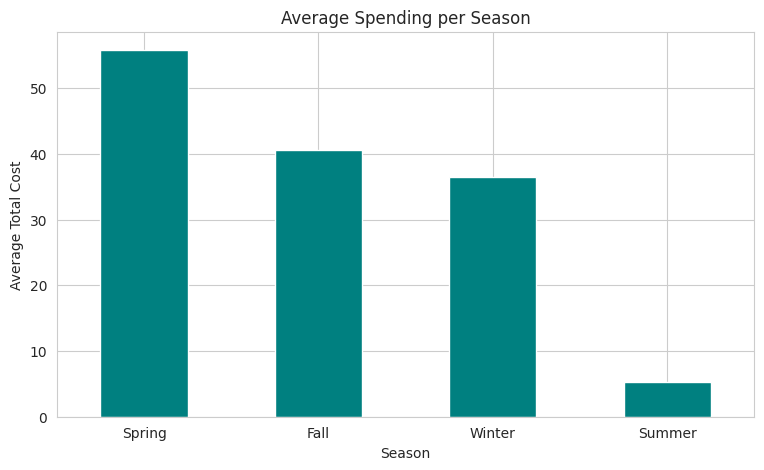

In [1]:
# Plot: average spending per season
avg_spend_by_season = df.groupby("Season")["Total_Cost"].mean().sort_values(ascending=False)
fig, ax = plt.subplots()
avg_spend_by_season.plot(kind="bar", color="teal", ax=ax)
ax.set_title("Average Spending per Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Total Cost")
plt.xticks(rotation=0)
fig.savefig(os.path.join(CHART_DIR, "avg_spending_per_season.png"), bbox_inches="tight", dpi=120)
plt.show()


## Task 6: Visualisation Dashboard

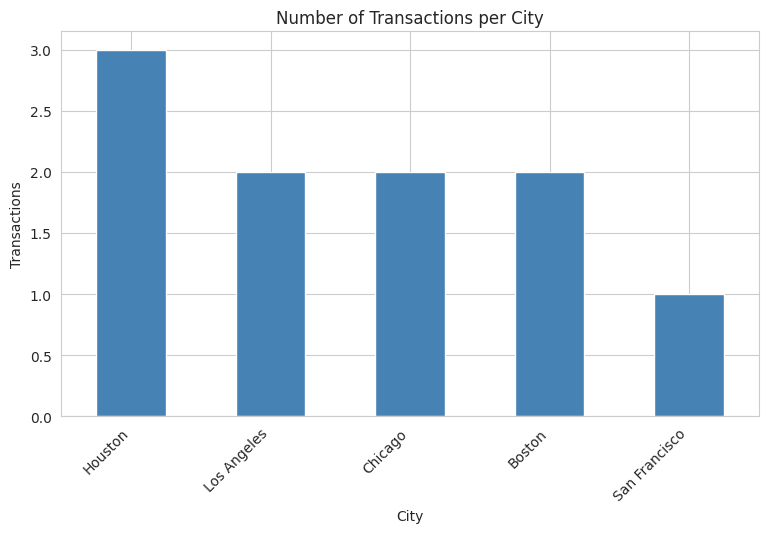

In [1]:
# 1. Bar plot: number of transactions per city
fig, ax = plt.subplots()
df["City"].value_counts().plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Number of Transactions per City")
ax.set_xlabel("City")
ax.set_ylabel("Transactions")
plt.xticks(rotation=45, ha="right")
fig.savefig(os.path.join(CHART_DIR, "transactions_per_city.png"), bbox_inches="tight", dpi=120)
plt.show()


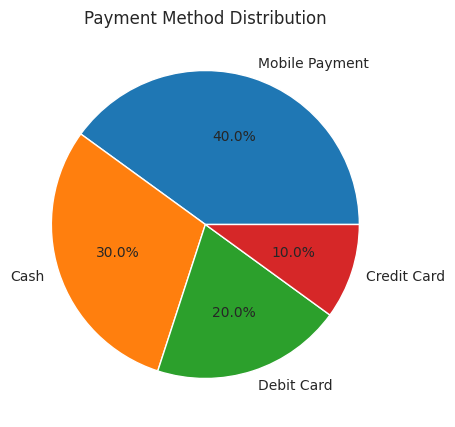

In [1]:
# 2. Pie chart: payment method distribution
fig, ax = plt.subplots()
df["Payment_Method"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax, ylabel="")
ax.set_title("Payment Method Distribution")
fig.savefig(os.path.join(CHART_DIR, "payment_method_distribution.png"), bbox_inches="tight", dpi=120)
plt.show()


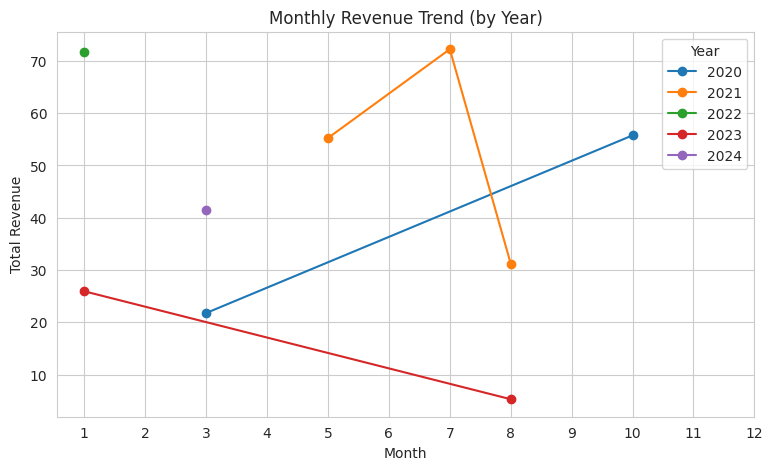

In [1]:
# 3. Line chart: monthly revenue trend (grouped by year)
monthly_revenue = df.groupby(["Year", "Month"])["Total_Cost"].sum().reset_index()
fig, ax = plt.subplots()
for year, grp in monthly_revenue.groupby("Year"):
    ax.plot(grp["Month"], grp["Total_Cost"], marker="o", label=str(int(year)))
ax.set_title("Monthly Revenue Trend (by Year)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.set_xticks(range(1, 13))
ax.legend(title="Year")
fig.savefig(os.path.join(CHART_DIR, "monthly_revenue_trend.png"), bbox_inches="tight", dpi=120)
plt.show()


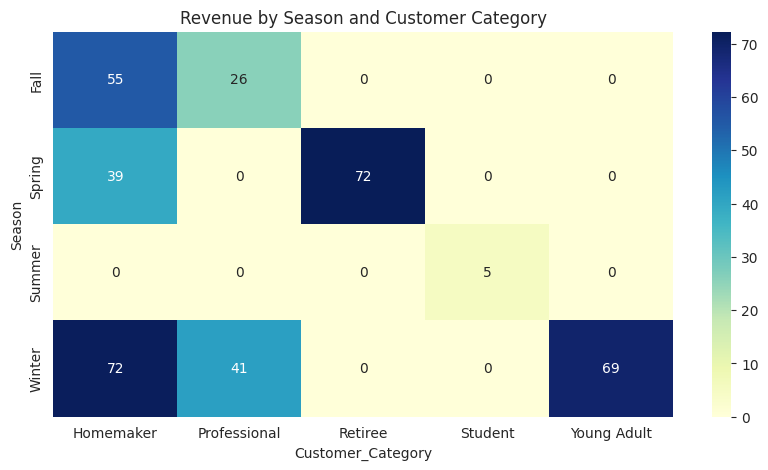

In [1]:
# 4. Heatmap: revenue by season and customer category
pivot = df.pivot_table(
    index="Season", columns="Customer_Category", values="Total_Cost", aggfunc="sum"
).fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
ax.set_title("Revenue by Season and Customer Category")
fig.savefig(os.path.join(CHART_DIR, "revenue_season_vs_category_heatmap.png"), bbox_inches="tight", dpi=120)
plt.show()


## Summary of Key Insights

In [1]:
top_city = top_cities.index[0]
top_product = top_products.index[0]
top_spender_category = avg_spend_by_category.index[0]
d_true = avg_cost_by_discount.get(True, float("nan"))
d_false = avg_cost_by_discount.get(False, float("nan"))

print(f'''
- Dataset covers {total_transactions} transactions from {unique_customers} unique customers.
- '{top_product}' was the most frequently purchased product overall.
- '{top_city}' recorded the highest number of transactions.
- '{top_spender_category}' customers spend the most on average per transaction.
- Discounted transactions averaged {d_true:.2f} vs {d_false:.2f} for non-discounted transactions.
- '{best_promo}' produced the highest average transaction value among all promotion types.
- '{top_season}' is the strongest-revenue season overall.

(These figures reflect the sample data currently in DATA_PATH. Re-run all
cells after swapping in the full Retail_Transactions_Dataset.csv to get the
real, submission-ready insights.)
''')



- Dataset covers 10 transactions from 10 unique customers.
- 'Olive Oil' was the most frequently purchased product overall.
- 'Houston' recorded the highest number of transactions.
- 'Retiree' customers spend the most on average per transaction.
- Discounted transactions averaged 46.98 vs 24.68 for non-discounted transactions.
- 'No Promotion' produced the highest average transaction value among all promotion types.
- 'Winter' is the strongest-revenue season overall.

(These figures reflect the sample data currently in DATA_PATH. Re-run all
cells after swapping in the full Retail_Transactions_Dataset.csv to get the
real, submission-ready insights.)

